In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
from datetime import timedelta


from cohorts.agency import plot_agency_cohorts


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('pipeline_data/cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

print(df_clean.shape)
# print(df_clean.dtypes)
# print(df_clean.head(3).to_string())

Loaded data: 37,008 quotes from 25,716 customers
(37008, 50)


In [2]:
print(df_clean['nom_agence'].value_counts())
print(f"\nTotal agencies: {df_clean['nom_agence'].nunique()}")

nom_agence
VB Gaz                           4585
Agence Caen                      3939
Chauffage du Nord                3612
SBF Energies                     3386
Agence Valognes                  3381
Agence Rouen                     2804
Roussin Energies                 2538
Agence Cherbourg                 1860
Agence Avranches                 1319
SMT Energies                     1277
SMEC                             1191
Mure Energies                    1145
Aujard                           1033
Agence Evreux                     976
GD Energies                       889
Lepretre                          771
Agence Quettehou                  639
Agence Les Moitiers d'Allonne     598
Lepretre Roclincourt              429
Agence Condé sur Vire             422
Lepretre Lievin                   214
Name: count, dtype: int64

Total agencies: 21


In [3]:
# When did each agency switch to the new process?
new_process = df_clean.groupby('nom_agence').agg(
    first_quote=('dt_creation_devis', 'min'),
    first_new_process=('dt_creation_devis', lambda x: x[df_clean.loc[x.index, 'fg_nouveau_process_relance_devis'] == 1].min()),
    pct_new_process=('fg_nouveau_process_relance_devis', 'mean'),
    total_quotes=('id_devis', 'count')
).reset_index()

new_process['pct_new_process'] = new_process['pct_new_process'] * 100
print(new_process.sort_values('first_new_process').to_string())

# Also check if conversion rate differs between old and new process
print("\nConversion rate by process flag:")
print(df_clean.groupby('fg_nouveau_process_relance_devis')['fg_devis_accepte'].mean())

                       nom_agence first_quote first_new_process  pct_new_process  total_quotes
0                Agence Avranches  2023-01-02        2024-10-01        31.235785          1319
18                           SMEC  2024-04-09        2024-10-01        80.772460          1191
17                   SBF Energies  2023-01-05        2024-10-01        58.800945          3386
16               Roussin Energies  2023-10-02        2024-10-01        68.203310          2538
8                 Agence Valognes  2023-01-02        2024-10-01        48.240166          3381
7                    Agence Rouen  2023-05-15        2024-10-01        47.289586          2804
10              Chauffage du Nord  2024-06-03        2024-10-01        83.582503          3612
5   Agence Les Moitiers d'Allonne  2023-01-03        2024-10-01        48.829431           598
4                   Agence Evreux  2023-05-16        2024-10-01        51.331967           976
3           Agence Condé sur Vire  2023-01-06     

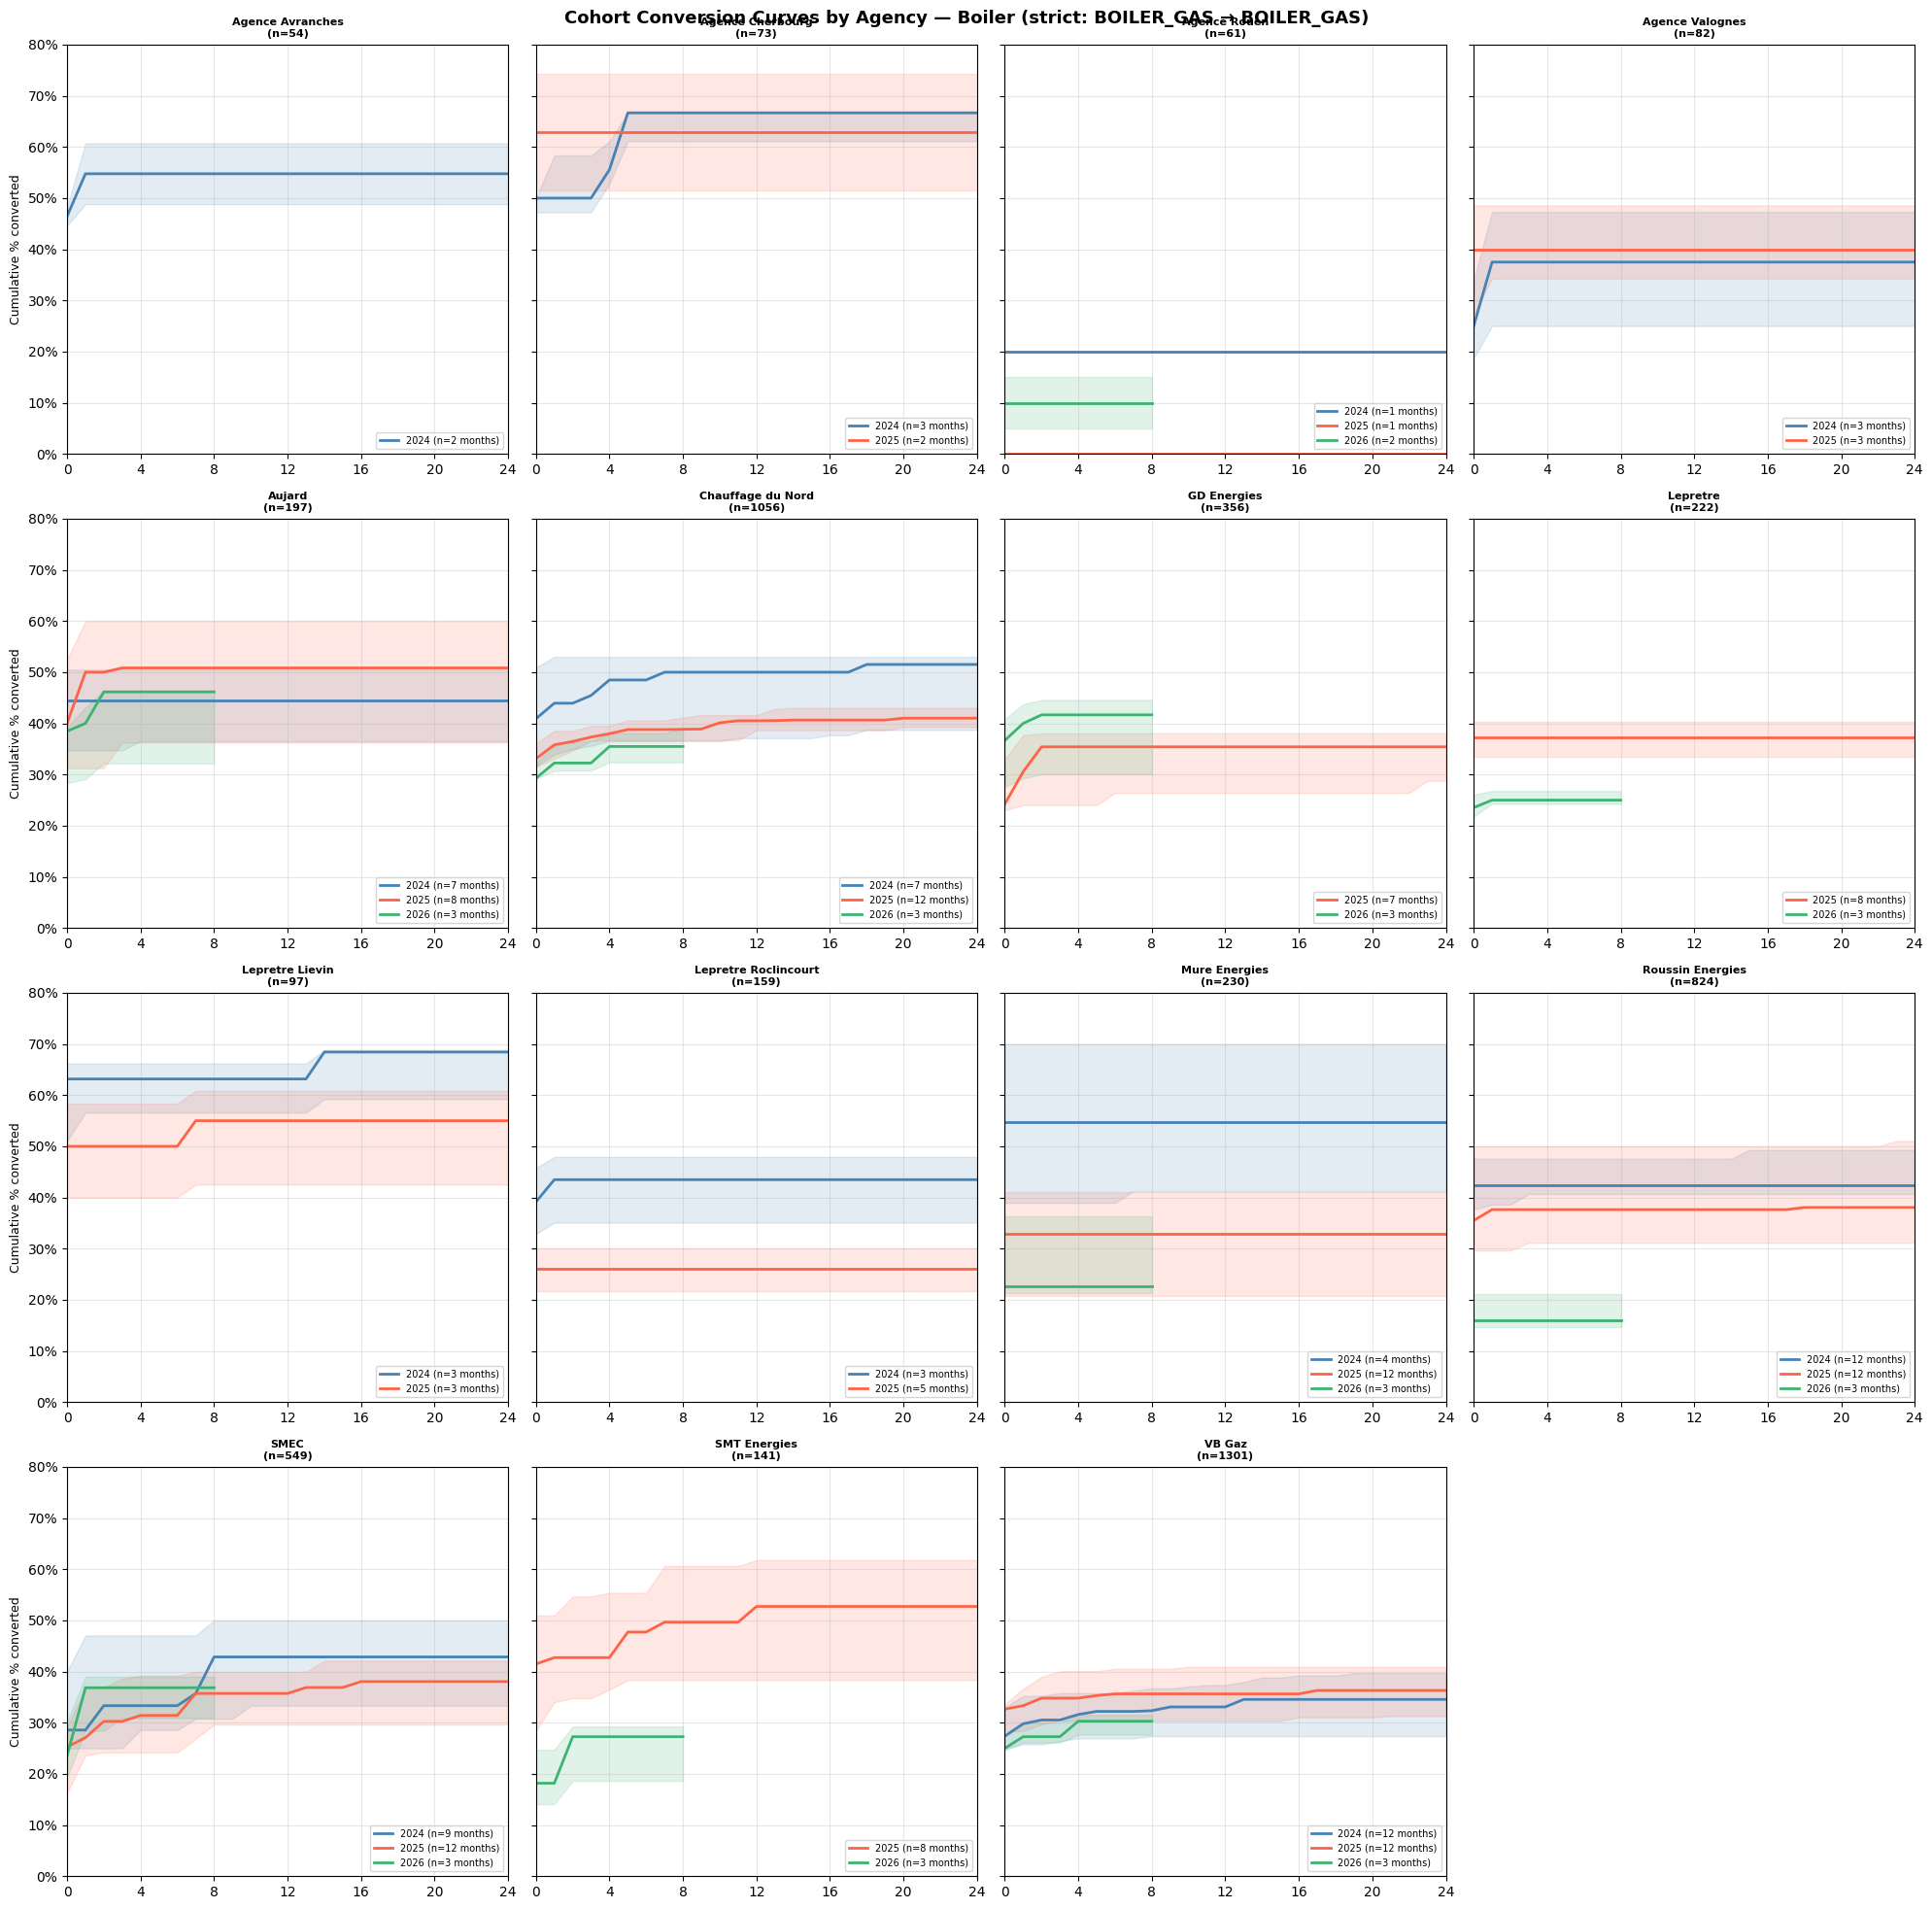

Saved: pipeline_data/cohort_curves_agency_boiler.png — 15 agencies plotted


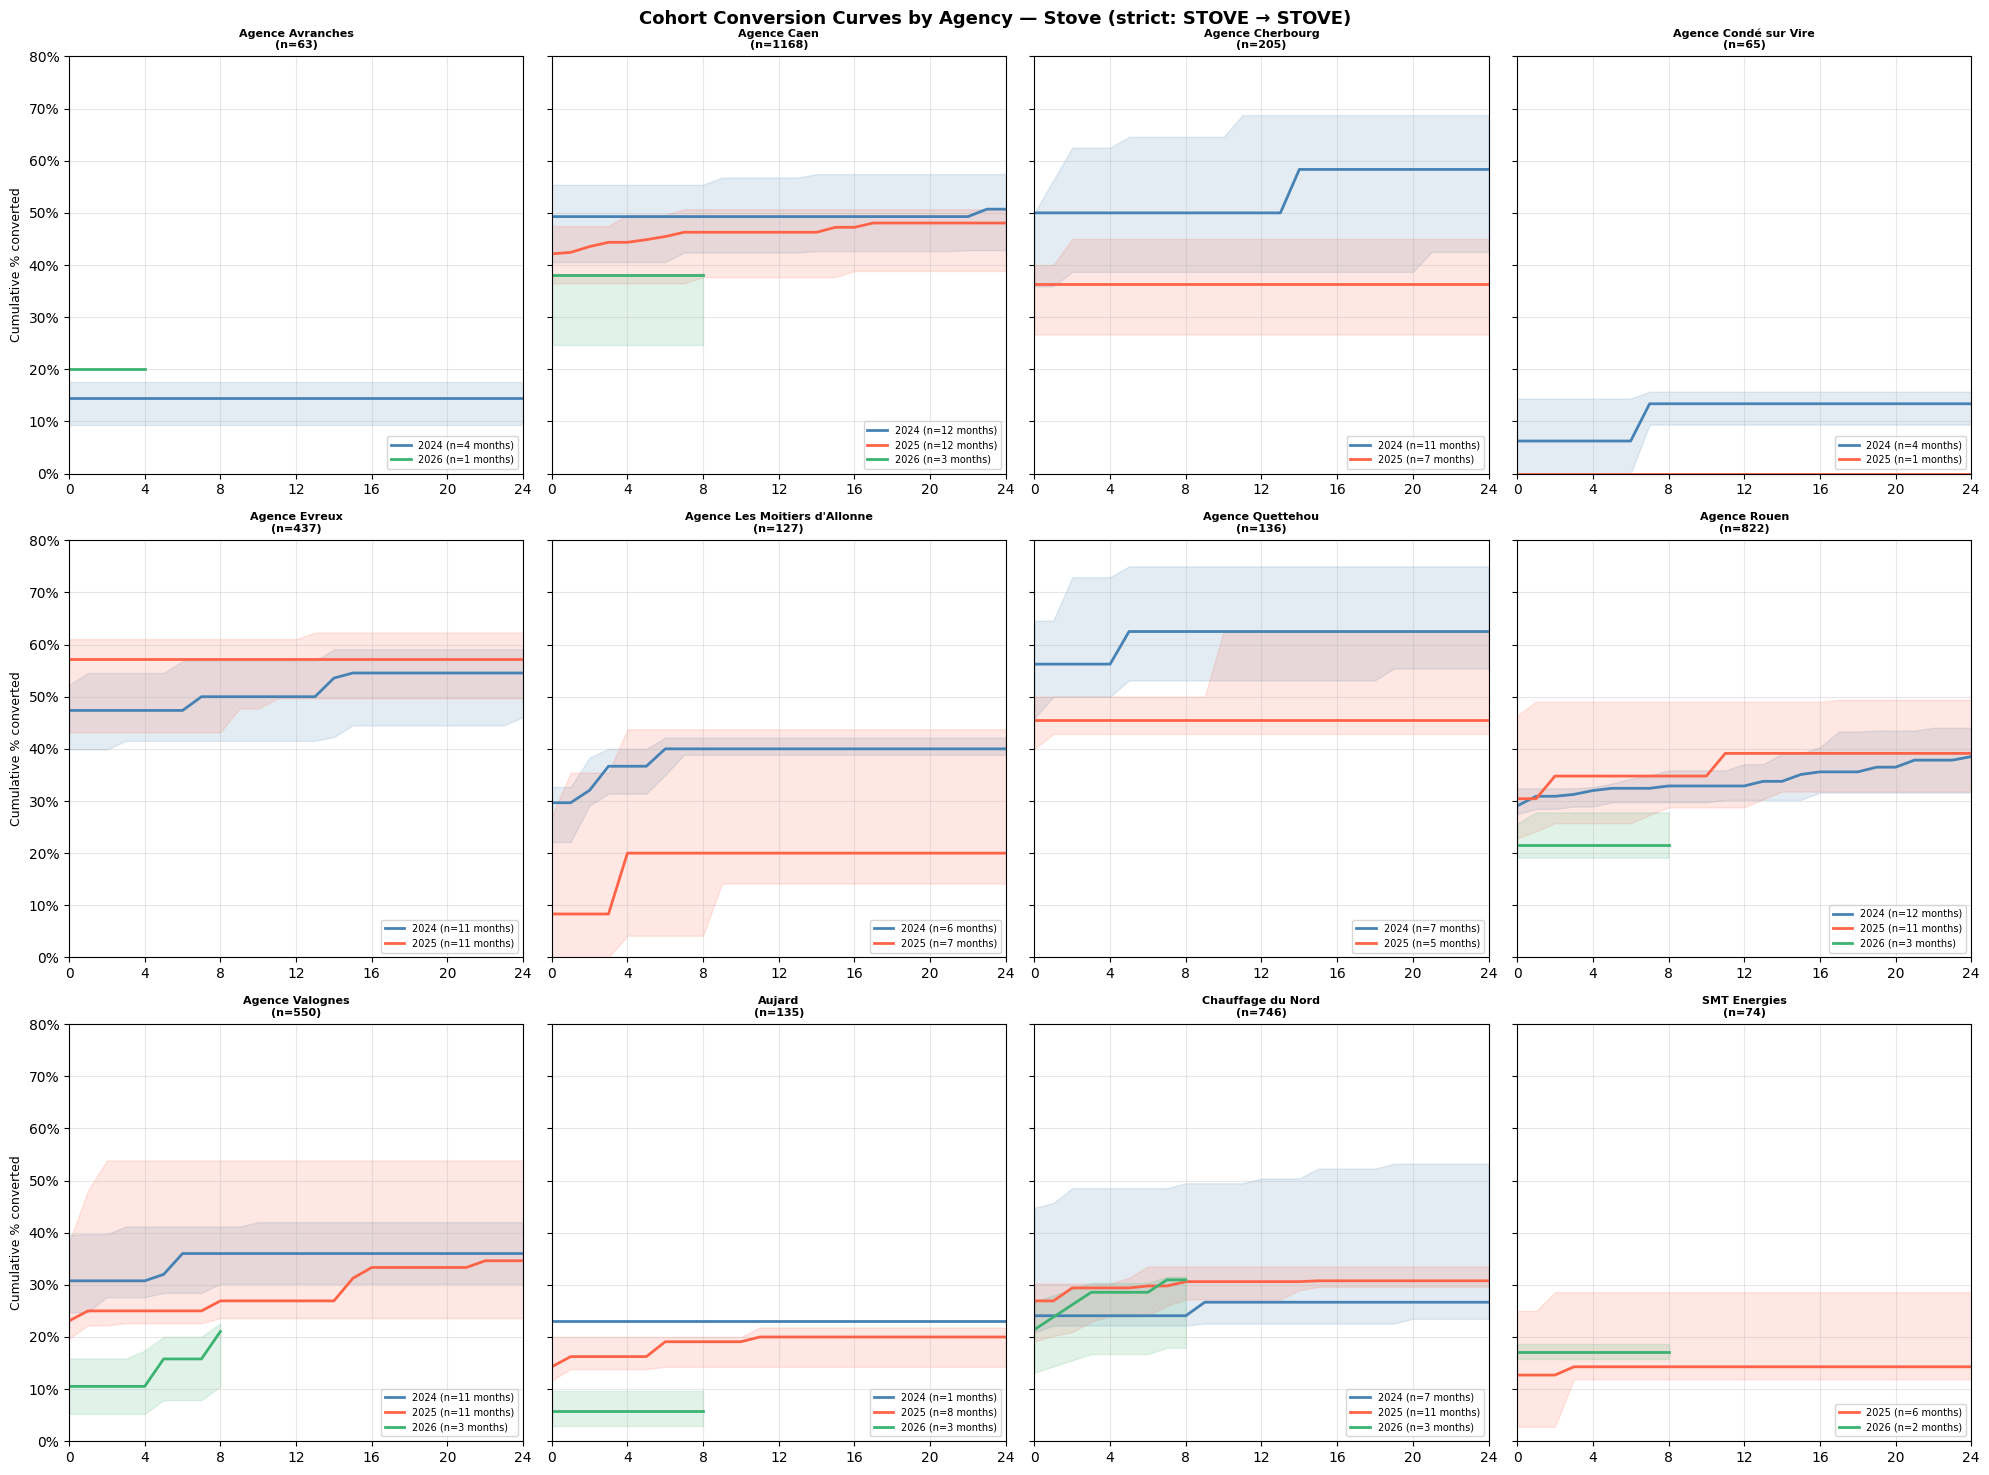

Saved: pipeline_data/cohort_curves_agency_stove.png — 12 agencies plotted


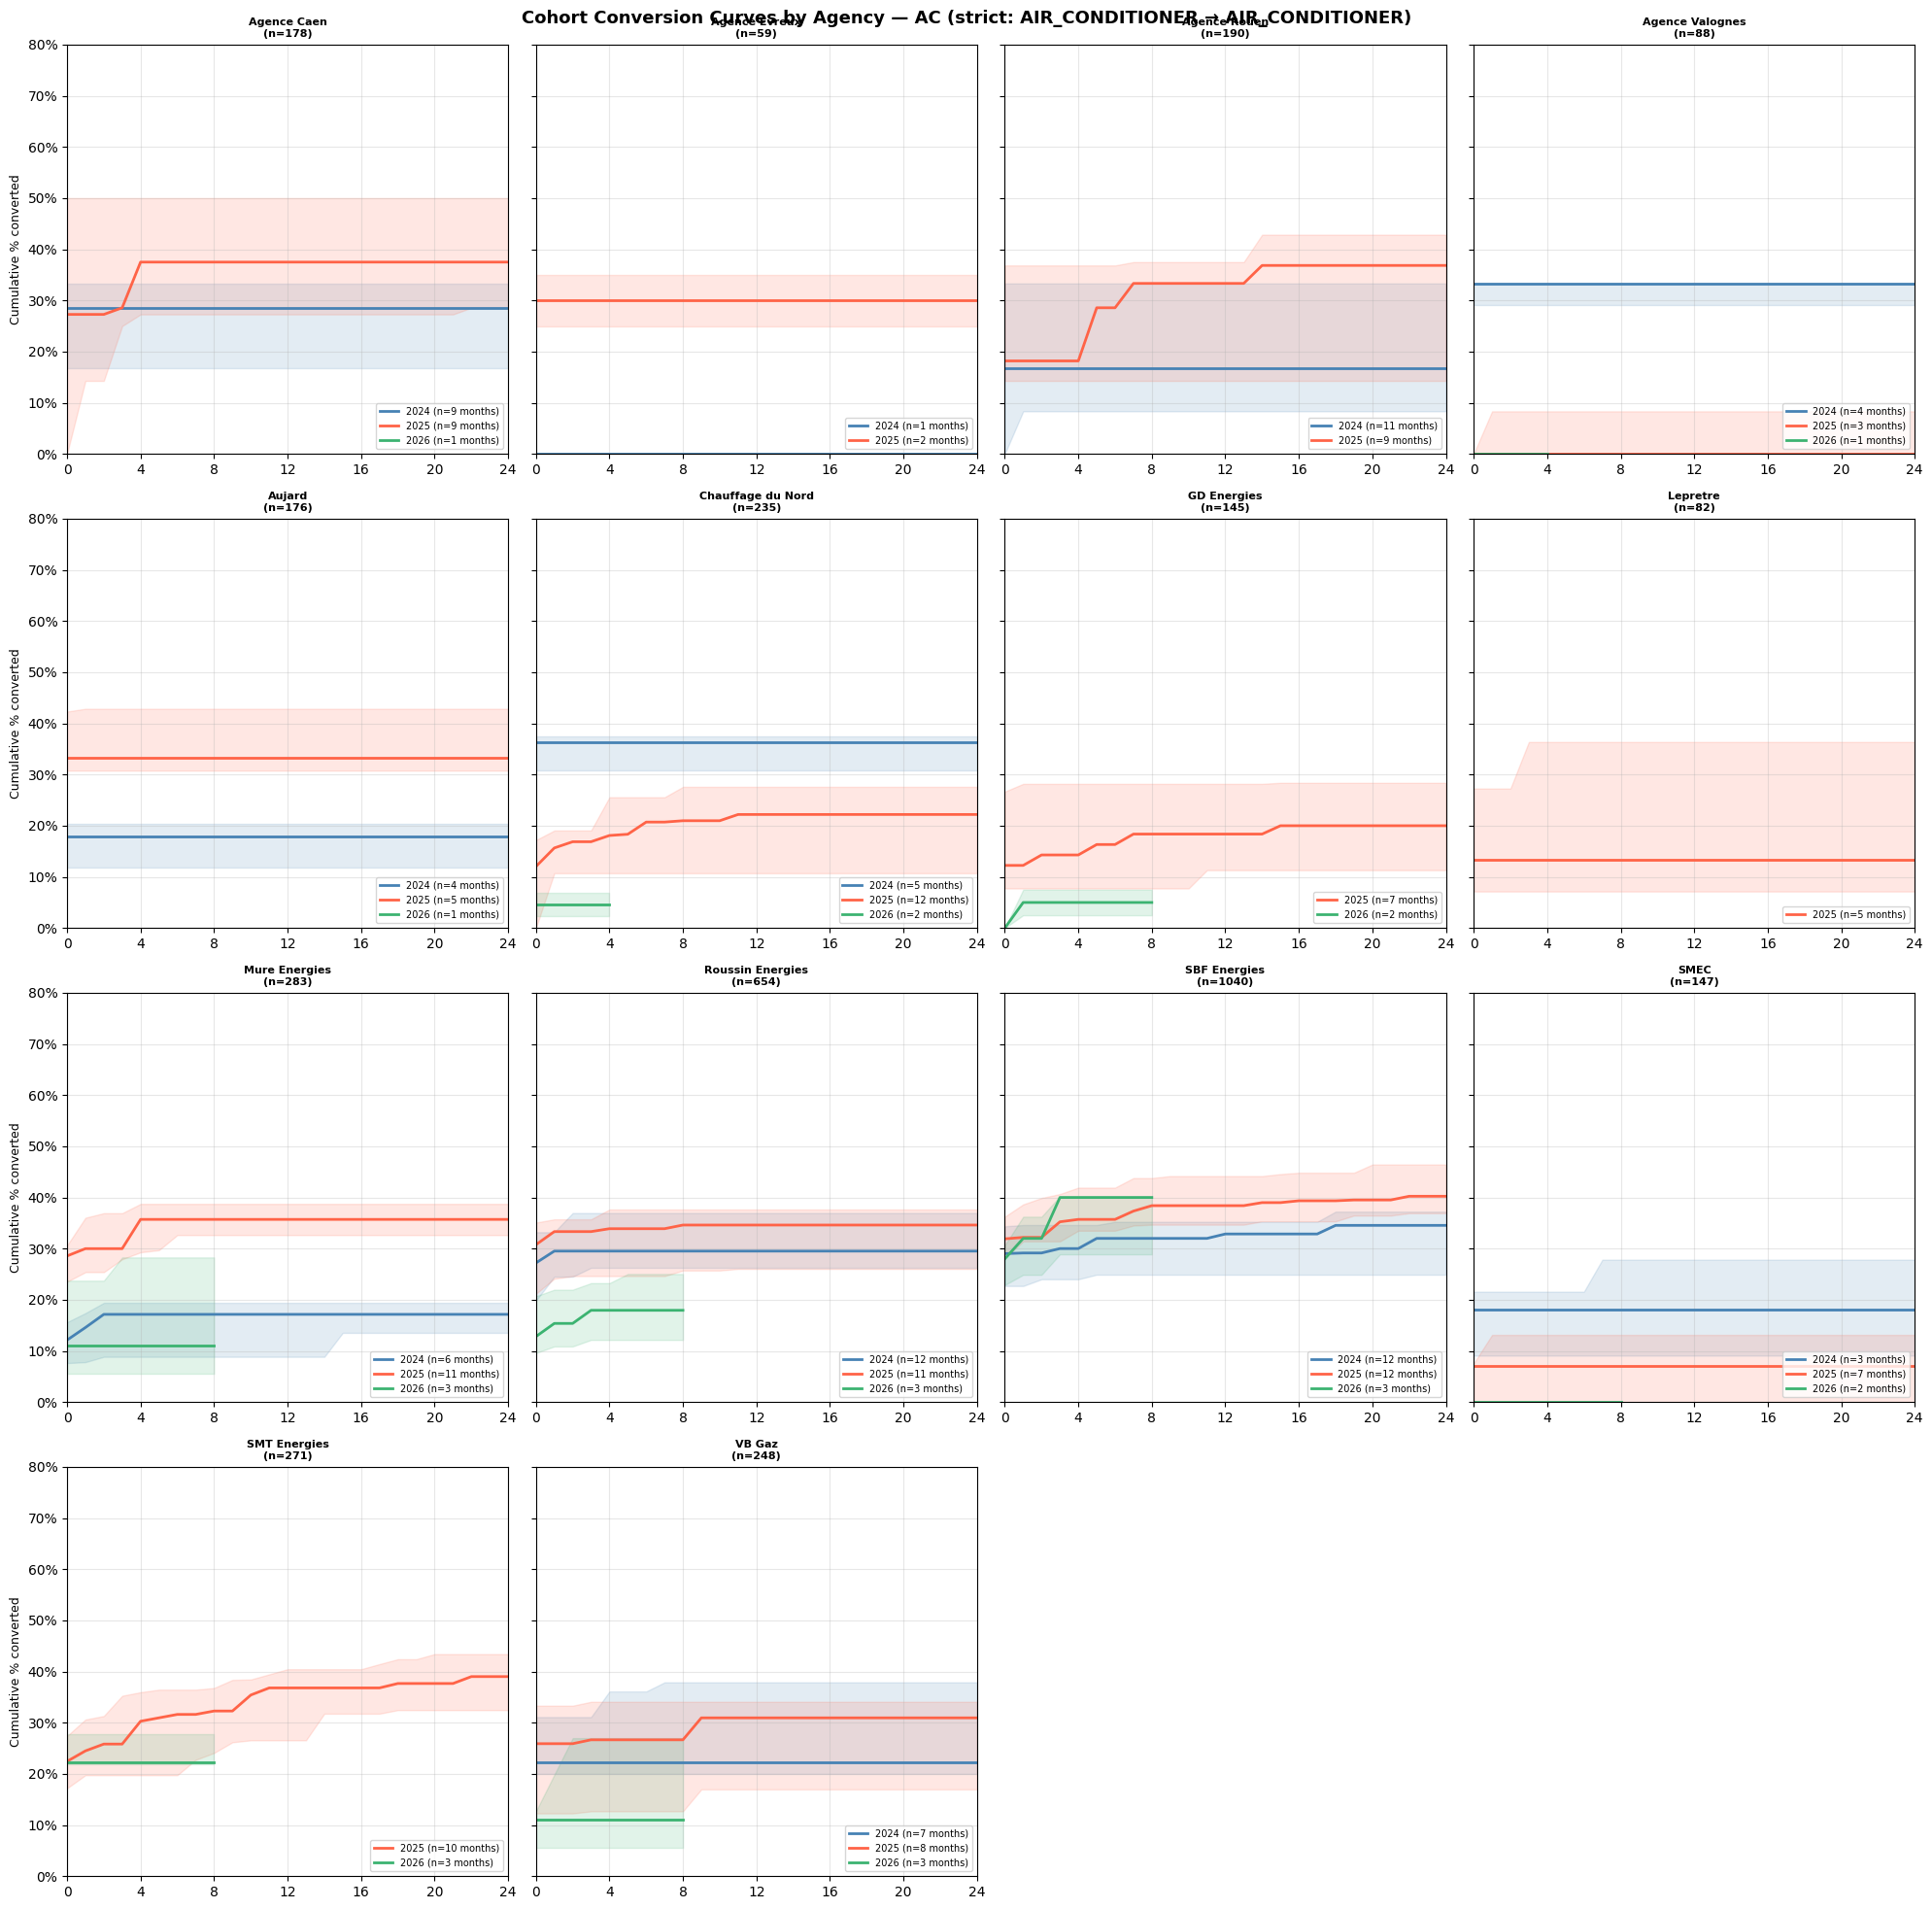

Saved: pipeline_data/cohort_curves_agency_ac.png — 14 agencies plotted


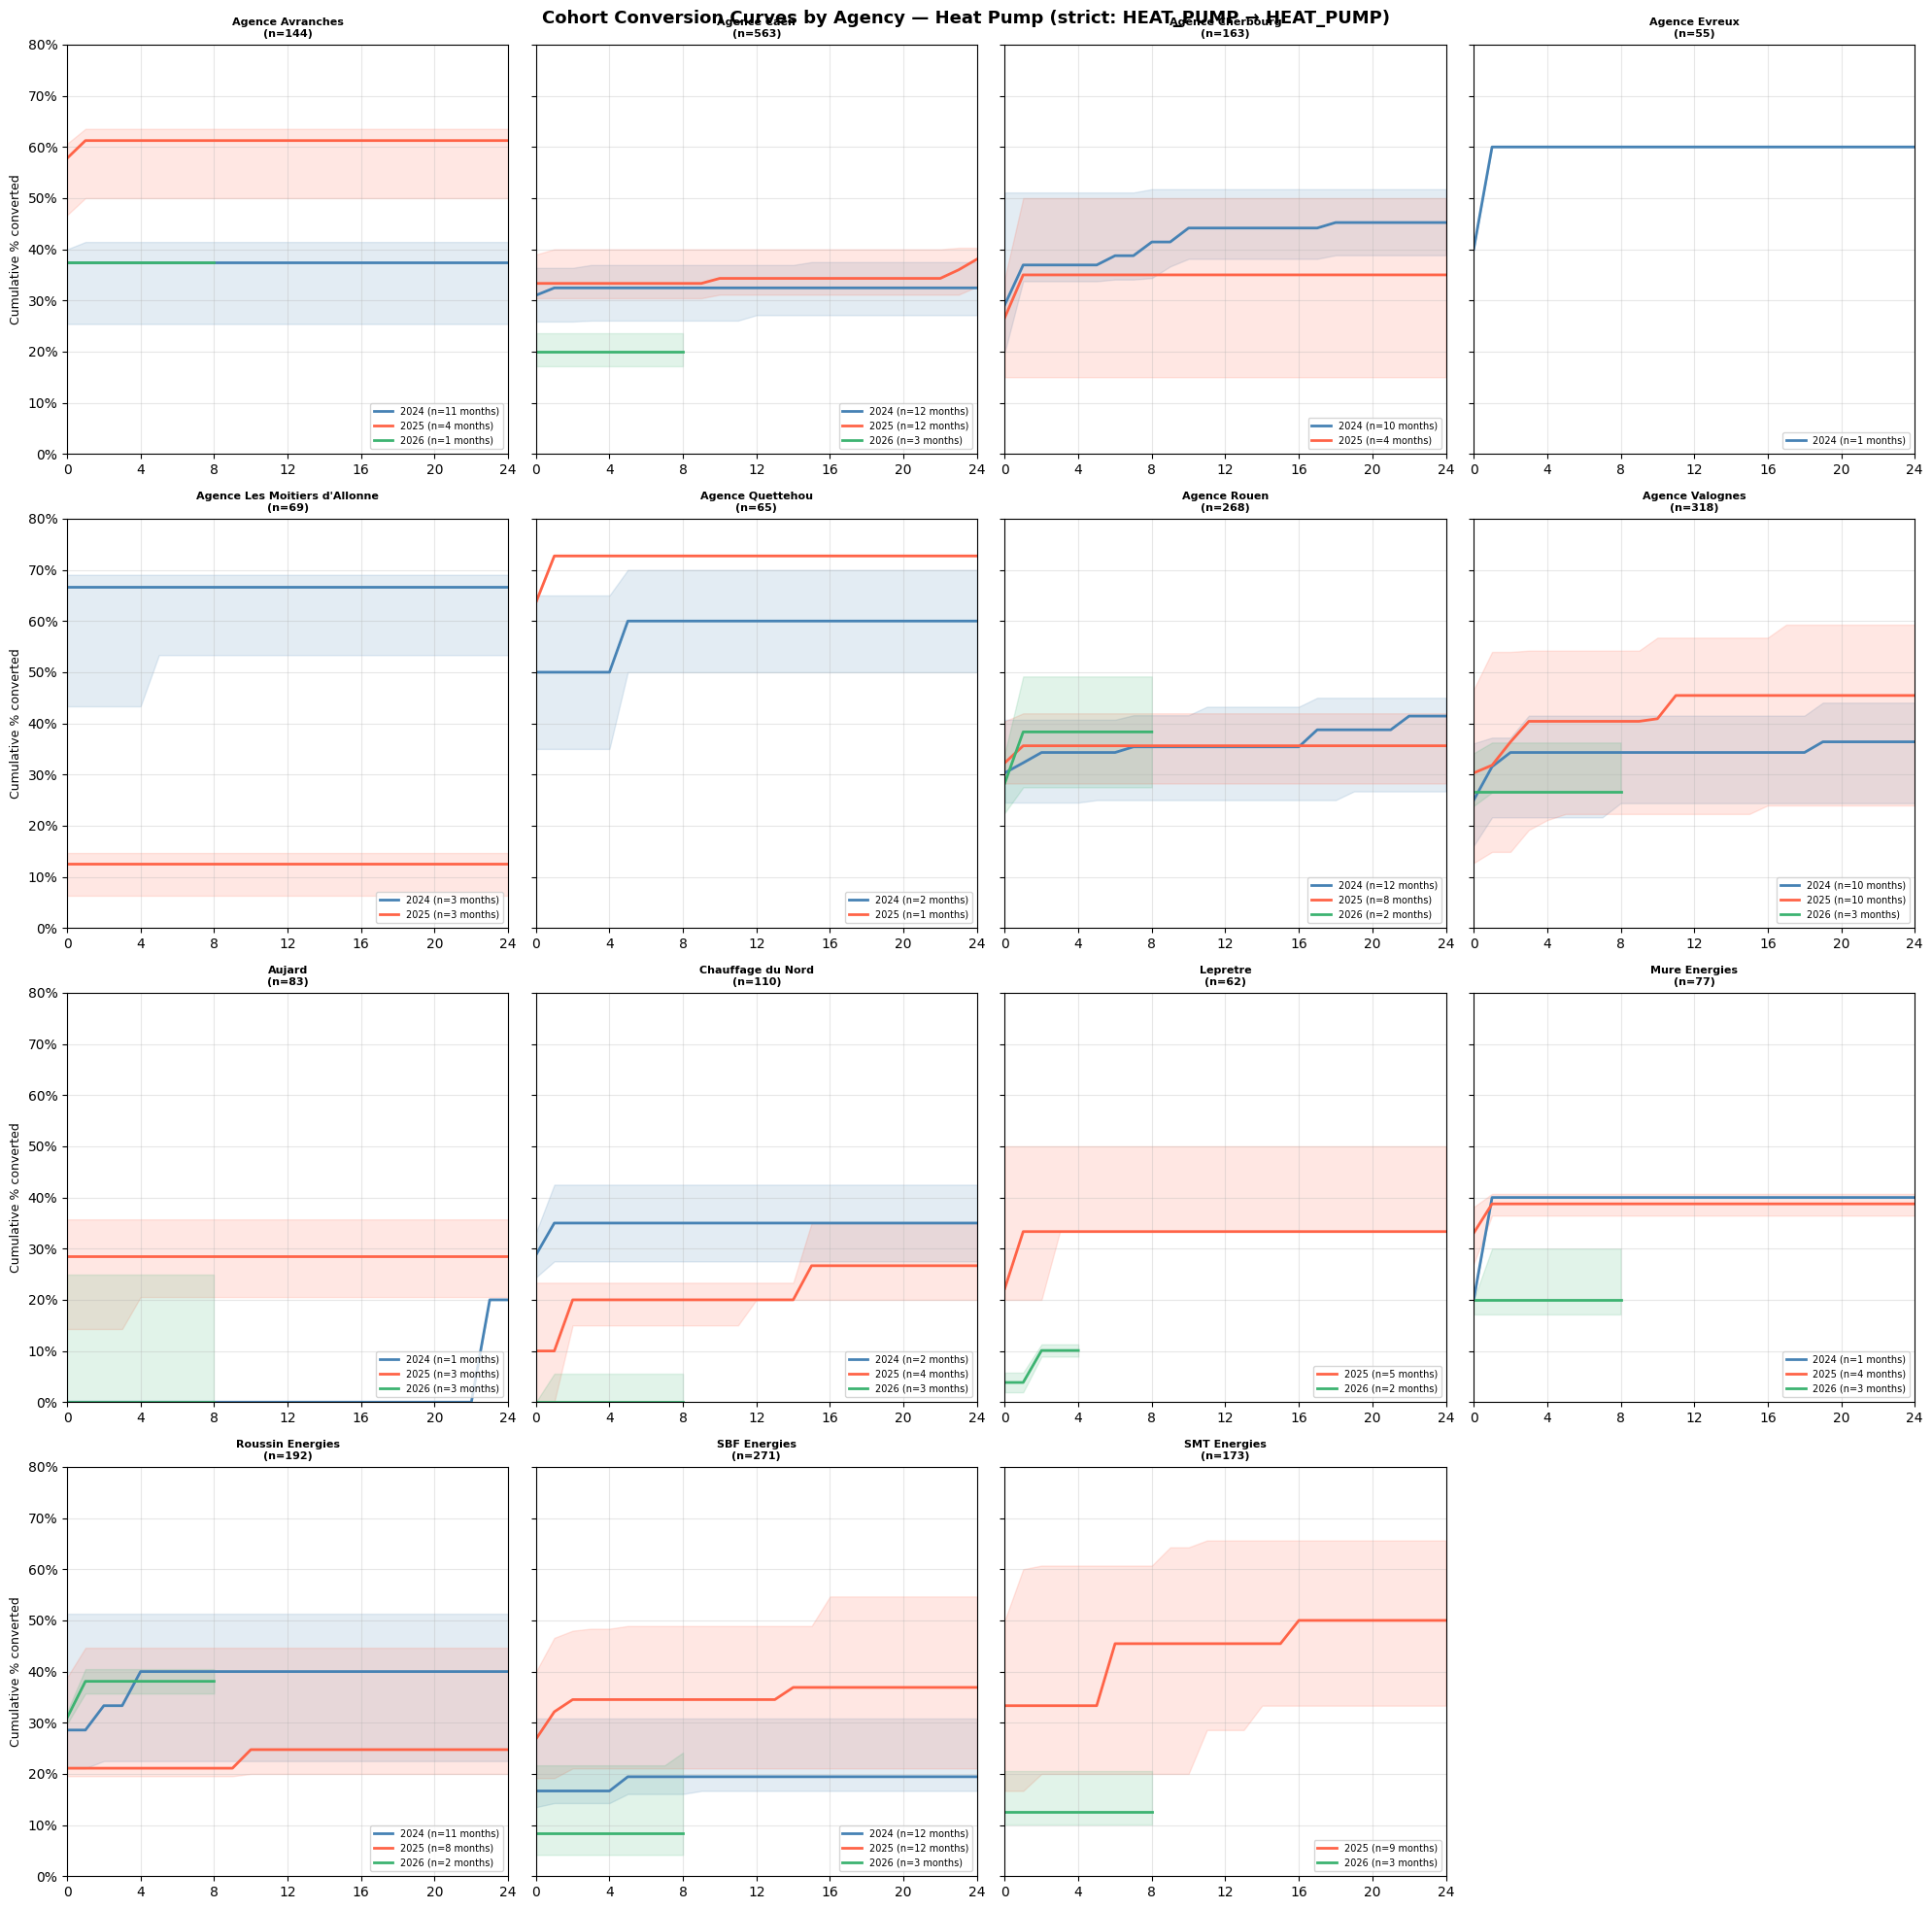

Saved: pipeline_data/cohort_curves_agency_heat_pump.png — 15 agencies plotted


In [4]:
plot_agency_cohorts(df_clean)